In [23]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
df=pd.read_csv("../../classes/master_dataset_partie2_2024_stint.csv")
df.head()


,Year,Event,Driver,Compound,CompoundEncoded,TyreLife,TrackTemp,FuelLoad,Abrasivity,LateralEnergy,DeltaToBest,LapNumber,Stint,CorrectedLapTime_Global,BestCorrectedByStint
0,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,4.0,31.8,54.0,3.1,3.1,0.000000,4.0,1.0,89.572000,89.572
1,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,5.0,31.7,53.0,3.1,3.1,0.490478,5.0,1.0,90.062478,89.572
2,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,6.0,31.8,52.0,3.1,3.1,0.107828,6.0,1.0,89.679828,89.572
3,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,7.0,31.8,51.0,3.1,3.1,0.432000,7.0,1.0,90.004000,89.572
4,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,8.0,31.9,50.0,3.1,3.1,0.549765,8.0,1.0,90.121765,89.572


In [24]:
# df final: Event, Abrasivity, LateralEnergy, TrackTemp moyen par circuit, FuelLoad au tour 1
df_source = df.copy()
df_source=df_source[df_source["Event"]!="Monaco Grand Prix"]
# Base par circuit
df_circuit = (
    df_source.groupby("Event", as_index=False).agg(
        Abrasivity=("Abrasivity", "mean"),
        LateralEnergy=("LateralEnergy", "mean"),
        TrackTemp=("TrackTemp", "mean"),
    )
)

# FuelLoad au tour 1 (moyenne des pilotes pour chaque circuit)
fuel_lap1 = (
    df_source[df_source["LapNumber"] == 1]
    .groupby("Event", as_index=False)
    .agg(FuelLoad=("FuelLoad", "mean"))
)

# Merge final
df = df_circuit.merge(fuel_lap1, on="Event", how="left")

df.head()

,Event,Abrasivity,LateralEnergy,TrackTemp,FuelLoad
0,Abu Dhabi Grand Prix,3.1,3.1,30.675293,NaN
1,Australian Grand Prix,2.8,3.1,38.567818,57.0
2,Austrian Grand Prix,2.4,3.1,46.412469,NaN
3,Azerbaijan Grand Prix,2.4,2.1,43.407530,NaN
4,Bahrain Grand Prix,4.8,3.2,22.780860,NaN


In [25]:

from sklearn.preprocessing import StandardScaler



df.drop(columns=["FuelLoad","TrackTemp"], inplace=True)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop(columns=["Event"]))

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(df_scaled)
df.head()



,Event,Abrasivity,LateralEnergy,Cluster
0,Abu Dhabi Grand Prix,3.1,3.1,2
1,Australian Grand Prix,2.8,3.1,2
2,Austrian Grand Prix,2.4,3.1,2
3,Azerbaijan Grand Prix,2.4,2.1,0
4,Bahrain Grand Prix,4.8,3.2,3


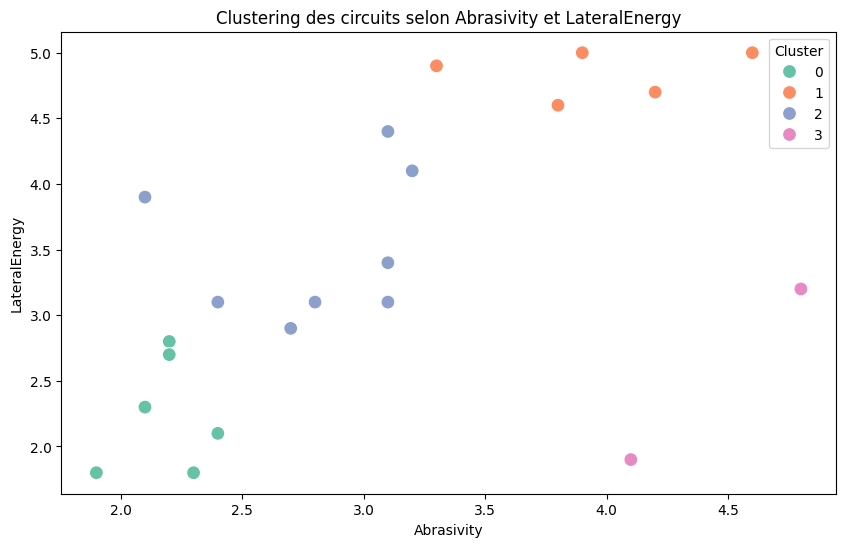

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Abrasivity", y="LateralEnergy", hue="Cluster", palette="Set2", s=100)
plt.title("Clustering des circuits selon Abrasivity et LateralEnergy")
plt.xlabel("Abrasivity")
plt.ylabel("LateralEnergy")
plt.show()

In [27]:
for cluster in df["Cluster"].unique():
    print(f"Cluster {cluster}:")
    print(df[df["Cluster"] == cluster][["Event", "Abrasivity", "LateralEnergy"]])
    print("\n")

Cluster 2:
                        Event  Abrasivity  LateralEnergy
0        Abu Dhabi Grand Prix         3.1            3.1
1       Australian Grand Prix         2.8            3.1
2         Austrian Grand Prix         2.4            3.1
8          Chinese Grand Prix         3.2            4.1
9            Dutch Grand Prix         3.1            4.4
10  Emilia Romagna Grand Prix         3.1            3.4
16           Miami Grand Prix         2.7            2.9
18   Saudi Arabian Grand Prix         2.1            3.9


Cluster 0:
                     Event  Abrasivity  LateralEnergy
3    Azerbaijan Grand Prix         2.4            2.1
7      Canadian Grand Prix         2.3            1.8
11    Hungarian Grand Prix         2.2            2.8
12      Italian Grand Prix         2.2            2.7
14    Las Vegas Grand Prix         1.9            1.8
15  Mexico City Grand Prix         2.1            2.3


Cluster 3:
                   Event  Abrasivity  LateralEnergy
4     Bahrain Grand 